<h2>Cvičenie 4 - Vizualizácia dát, práca s knižnicou <code>ggplot2</code></h2>
        <p>Cieľom štvrtého cvičenia je naučiť sa základné možnosti vizuálizácia dát a používať knižnicou <code>ggplot2</code>, ktorá poskytuje platformu na vytváranie jednoduchých grafov poskytujúcixh množstvo informácií.</p>
      
<p> Na začiatok si ukážeme základné možnosti vizualízácie dát. </p>
<h3>Prieskum dát</h3>
<p> Po načítaní údajov do pracovného priestoru je čas ich preskúmať a získať predstavu o ich štruktúre:</p>

In [2]:
download.file("http://people.tuke.sk/peter.butka/res/avgpm25.csv","DATA/avgpm25.csv")
pollution =  read.csv("DATA/avgpm25.csv", colClasses = c("numeric", "character","factor", "numeric", "numeric"))

In [3]:
head(pollution)

,pm25,fips,region,longitude,latitude
,<dbl>,<chr>,<fct>,<dbl>,<dbl>
1,9.771185,01003,east,-87.74826,30.59278
2,9.993817,01027,east,-85.84286,33.26581
3,10.688618,01033,east,-87.72596,34.73148
4,11.337424,01049,east,-85.79892,34.45913
5,12.119764,01055,east,-86.03212,34.01860
6,10.827805,01069,east,-85.35039,31.18973


In [4]:
tail(pollution,7)

,pm25,fips,region,longitude,latitude
,<dbl>,<chr>,<fct>,<dbl>,<dbl>
570,8.505596,56013,west,-108.6811,43.09821
571,4.132739,56021,west,-104.7621,41.19620
572,4.955570,56029,west,-108.9990,44.56896
573,6.549239,56033,west,-106.9681,44.78363
574,5.632587,56035,west,-109.9911,42.75095
575,6.349710,56037,west,-109.1682,41.64071
576,4.565808,56039,west,-110.6735,43.61212


In [5]:
summary(pollution)

      pm25            fips            region      longitude      
 Min.   : 3.383   Length:576         east:442   Min.   :-158.04  
 1st Qu.: 8.549   Class :character   west:134   1st Qu.: -97.38  
 Median :10.047   Mode  :character              Median : -87.37  
 Mean   : 9.836                                 Mean   : -91.65  
 3rd Qu.:11.356                                 3rd Qu.: -80.72  
 Max.   :18.441                                 Max.   : -68.26  
    latitude    
 Min.   :19.68  
 1st Qu.:35.30  
 Median :39.09  
 Mean   :38.56  
 3rd Qu.:41.75  
 Max.   :64.82  

In [6]:
str(pollution)

'data.frame':	576 obs. of  5 variables:
 $ pm25     : num  9.77 9.99 10.69 11.34 12.12 ...
 $ fips     : chr  "01003" "01027" "01033" "01049" ...
 $ region   : Factor w/ 2 levels "east","west": 1 1 1 1 1 1 1 1 1 1 ...
 $ longitude: num  -87.7 -85.8 -87.7 -85.8 -86 ...
 $ latitude : num  30.6 33.3 34.7 34.5 34 ...


<h3>Základné grafy</h3> 

<p><samp>Graphics</samp> je vstavaným balíkom R a využíva sa na vykresľovanie <samp>base</samp> grafov.
<p>Pozrime sa na použitie základných grafov:</p>

In [7]:
# Zoznam všetkých funkcií získate zadaním:
library(help = "graphics")

Documentation for package ‘graphics’


		Information on package ‘graphics’

Description:

Package:            graphics
Version:            4.2.2
Priority:           base
Title:              The R Graphics Package
Author:             R Core Team and contributors worldwide
Maintainer:         R Core Team <do-use-Contact-address@r-project.org>
Contact:            R-help mailing list <r-help@r-project.org>
Description:        R functions for base graphics.
Imports:            grDevices
License:            Part of R 4.2.2
NeedsCompilation:   yes
Built:              R 4.2.2; x86_64-conda-linux-gnu; 2022-12-16
                    04:05:17 UTC; unix

Index:

Axis                    Generic Function to Add an Axis to a Plot
abline                  Add Straight Lines to a Plot
arrows                  Add Arrows to a Plot
assocplot               Association Plots
axTicks                 Compute Axis Tickmark Locations
axis                    Add an Axis to a Plot
axis.POSIXct            Date and 

In [8]:
# Nápovedu k funkciám si vieme zobraziť aj použitím funkcie help()
help(hist)

hist {graphics},R Documentation
x,a vector of values for which the histogram is desired.
breaks,"one of: a vector giving the breakpoints between histogram cells, a function to compute the vector of breakpoints, a single number giving the number of cells for the histogram, a character string naming an algorithm to compute the number of cells (see ‘Details’), a function to compute the number of cells. In the last three cases the number is a suggestion only; as the breakpoints will be set to pretty values, the number is limited to 1e6 (with a warning if it was larger). If breaks is a function, the x vector is supplied to it as the only argument (and the number of breaks is only limited by the amount of available memory)."
freq,"logical; if TRUE, the histogram graphic is a representation of frequencies, the counts component of the result; if FALSE, probability densities, component density, are plotted (so that the histogram has a total area of one). Defaults to TRUE if and only if breaks are equidistant (and probability is not specified)."
probability,"an alias for !freq, for S compatibility."
include.lowest,"logical; if TRUE, an x[i] equal to the breaks value will be included in the first (or last, for right = FALSE) bar. This will be ignored (with a warning) unless breaks is a vector."
right,"logical; if TRUE, the histogram cells are right-closed (left open) intervals."
fuzz,"non-negative number, for the case when the data is “pretty” and some observations x[.] are close but not exactly on a break. For counting fuzzy breaks proportional to fuzz are used. The default is occasionally suboptimal."
density,"the density of shading lines, in lines per inch. The default value of NULL means that no shading lines are drawn. Non-positive values of density also inhibit the drawing of shading lines."
angle,"the slope of shading lines, given as an angle in degrees (counter-clockwise)."
col,a colour to be used to fill the bars. The default used to be NULL (unfilled bars) in R versions before 4.0.0.


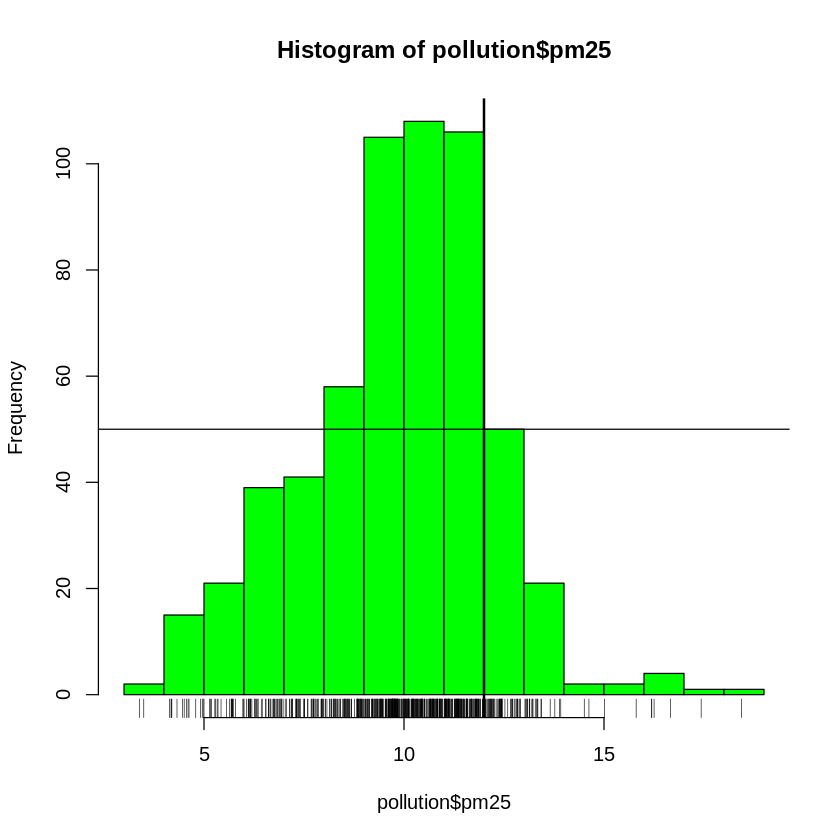

In [9]:
# 1. histogram
hist(pollution$pm25, col = "green")      # histogram pm25, zelená farba
rug(pollution$pm25)                      # "koberec" :)
abline(v = 12, lwd = 2)                  # pridanie čiary vertikálne na čislo 12, hrúbka 2
abline(h=50)                             # pridanie čiary horizontalne na čislo 50

 

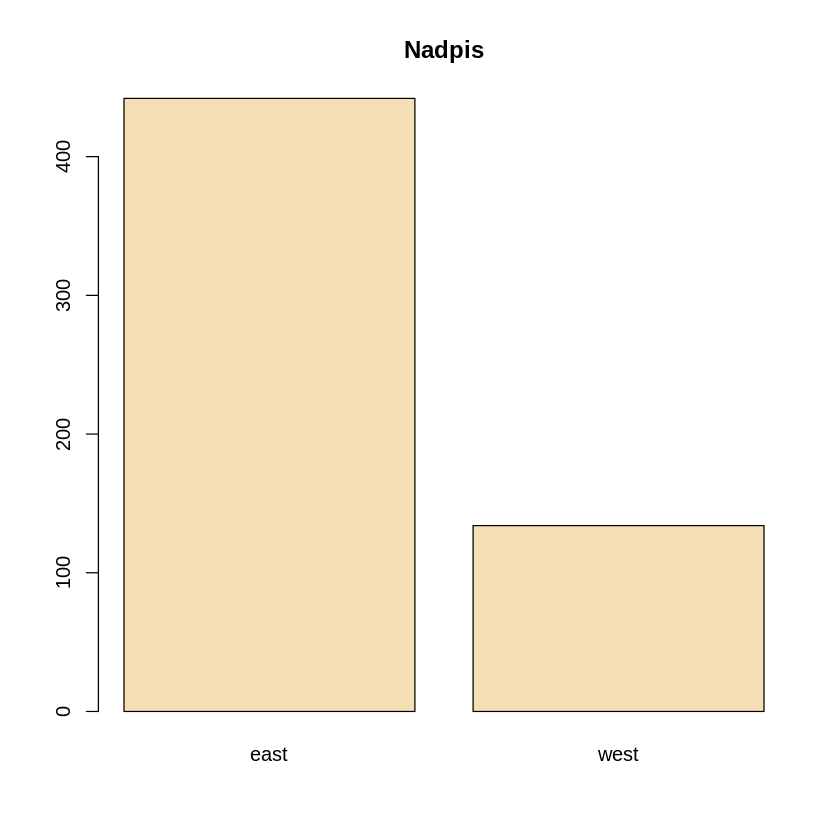

In [10]:
# 2. barplot
barplot(table(pollution$region), col = "wheat", main = "Nadpis")  # BARPLOT, pre stlpec region, s danou farbou a nadpisom

<h4>Boxplot</h4> 
<img src="https://datalab.kkui.fei.tuke.sk/www/JDA/cvi%C4%8Denia%20R/img/boxplot.png"  width="600" height="300">

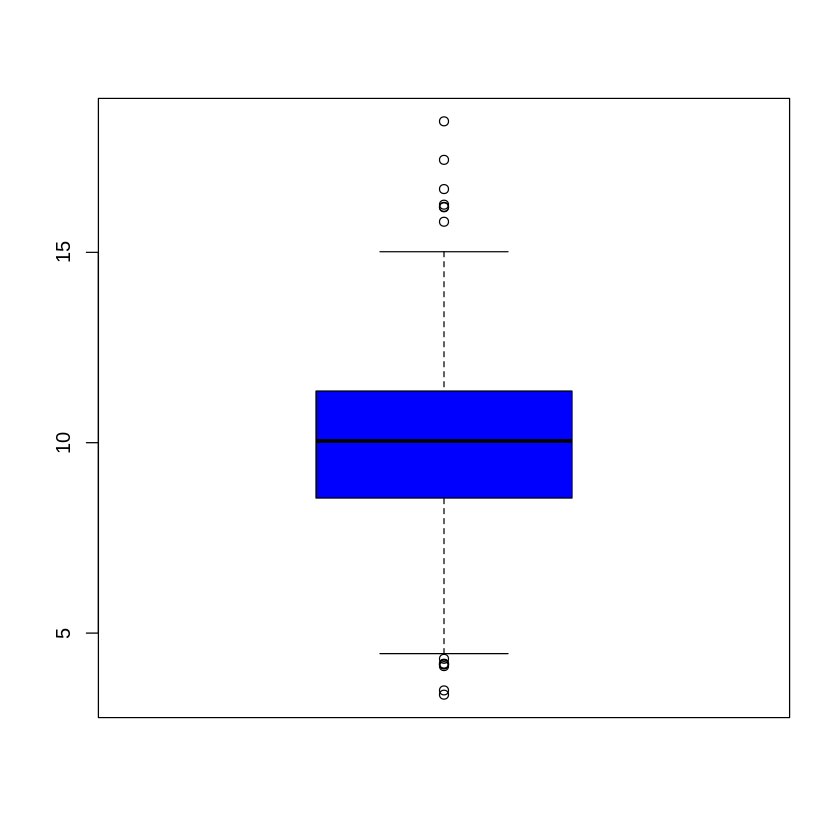

In [11]:
# 3. boxplot
boxplot(pollution$pm25, col = "blue")                     # boxplot atribútu pm25, farba modrá

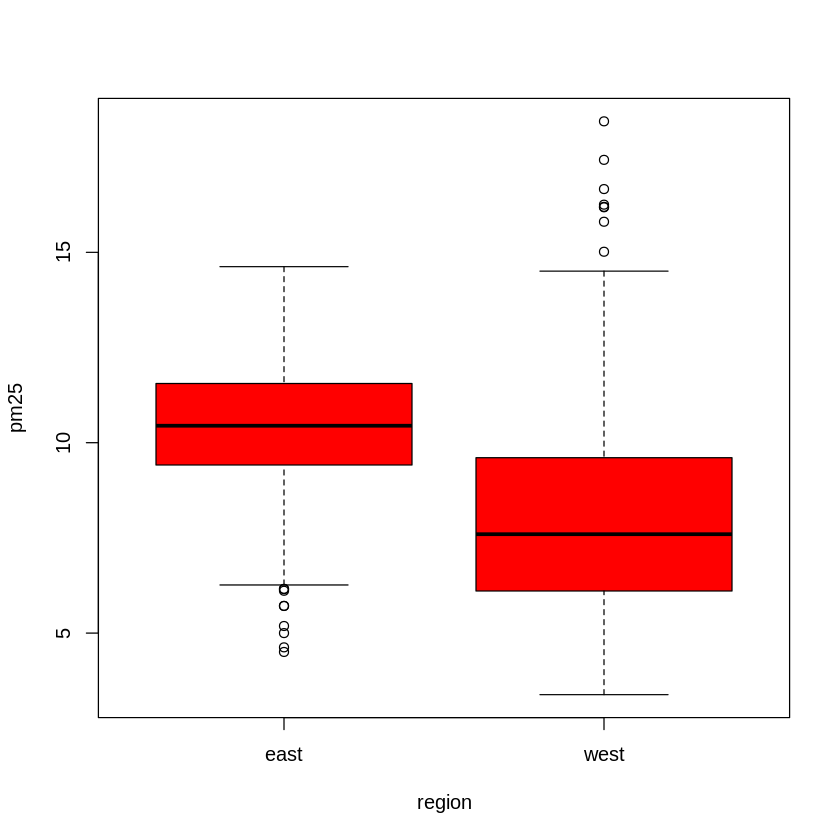

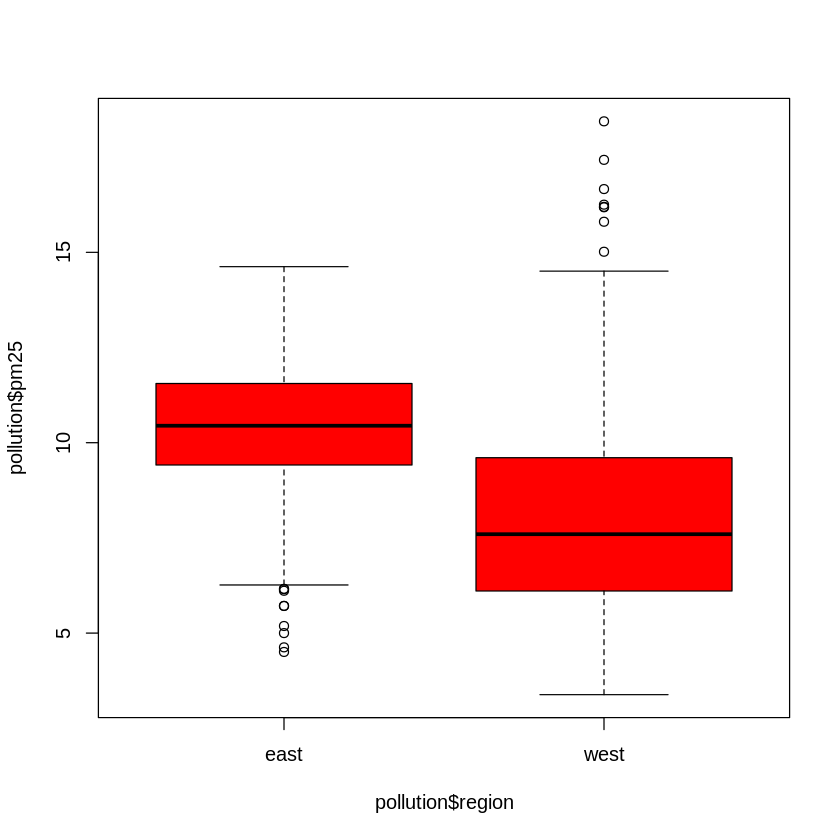

In [12]:
boxplot(pm25 ~ region, data = pollution, col = "red")     # boxplot pre 2 atribúty
# or
boxplot(pollution$pm25 ~ pollution$region, col = "red")

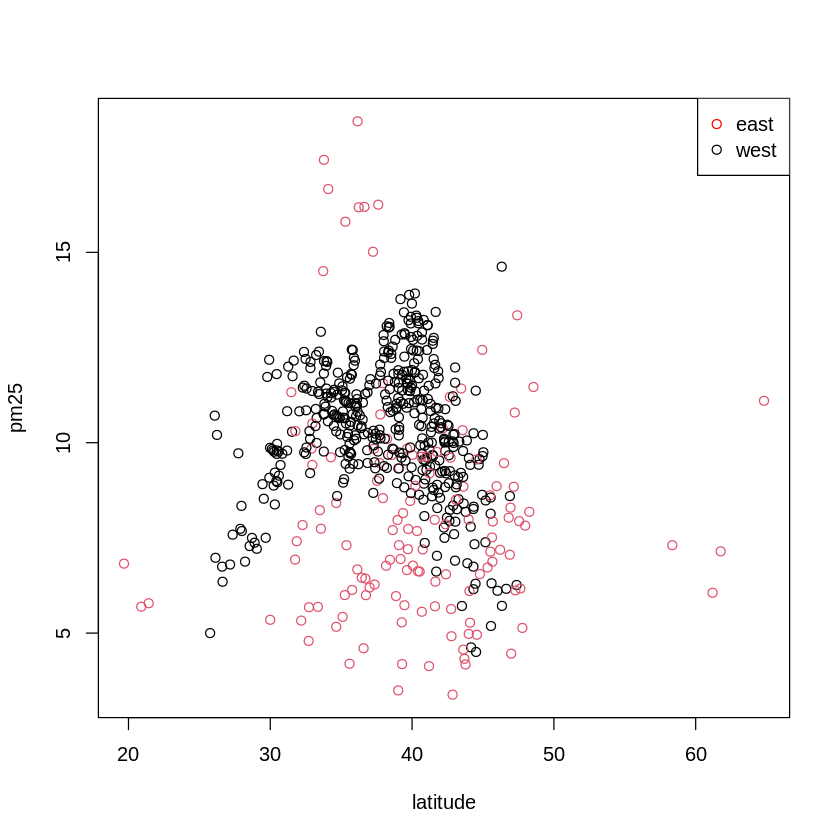

In [13]:
# 4.scatterplot
# scatterplot (bodový graf) z dát pollution, pre latitude a pm25 a rozdelenie regionov podla farieb
with(pollution, plot(latitude, pm25, col = region))  
# legenda, vpravo hore, názvy legendy su levels v regione, farby, typ oznacenia
legend(x="topright", legend = levels(pollution$region), col=c("red","black"),pch=1)

<h3>Knižnica <code>ggplot2</code> </h3>  
          <p>Balík <code>ggplot2</code> je róbustný a všestraný balík, ktorý vyvinul Hadley Wickham na vytváranie estetických grafov a máp. V tejto časti sa pozrieme na niekoľko 
            príkladov a tipov ako používať balík <code>ggplot2</code> na vizualizáciu dát. 
            <p><code>Ggplot2</code> vytvára akúsi "gramatiku", pomocou ktorej vieme zápis rozdeliť do troch základných častí:</p>
            <pre>plot = data + aesthetics + geometry </pre>
            <ul>   
              <li>  <b>data:</b> dataset (datový rámec) </li>
              <li> <b>aesthetics:</b> označuje premenné <samp>x</samp> a <samp>y</samp>  a zároveň definuje ich vlastnosti (farba, veľkosť, tvar bodov atď) </li>
              <li> <b>geometry:</b> označuje TYP grafiky, t.j. či ide o stĺpcový graf, histogram, boxplot atď.</li>
            </ul>
            <p>K tejto základnej gramatike môžeme pridávať, ďalšie prvky ako popis osí, nadpis grafu, legendu, zmenu témy a mnoho iného. 
              V nasledujúucich úlohach si ukážeme niektoré z nich.</p>
              <pre>plot = ggplot(data, aes()) + geometry + ... </pre>   
<p>V nasledujúcich úlohách budeme používať 2 datasety dostupné v R:</p>
<ol>
   <p><li><b> iris:</b> 50 pozorovaní, 5 premenných </li>   </p>
   <img src="https://datalab.kkui.fei.tuke.sk/www/JDA/cvi%C4%8Denia%20R/img/iris.png"  width="400" height="350">    --- >          <img src="https://datalab.kkui.fei.tuke.sk/www/JDA/cvi%C4%8Denia%20R/img/iriis.png"  width="350" height="350">
   <p><li><b> Titanic:</b> 32 pozorovaní, 5 premenných </li>  </p>
   <img src="https://datalab.kkui.fei.tuke.sk/www/JDA/cvi%C4%8Denia%20R/img/tita.png"  width="250">  < ---  <img src="https://datalab.kkui.fei.tuke.sk/www/JDA/cvi%C4%8Denia%20R/img/titanic.png"  width="500"> 
</ol>


In [14]:
# Pre inštaláciu balíka zadajte
#install.packages("ggplot2")
# a načítajte knižnicu pomocou nasledujúceho príkazu:
library(ggplot2)

<h4>Histogram</h4> 

`stat_bin()` using `bins = 30`. Pick better value with `binwidth`.


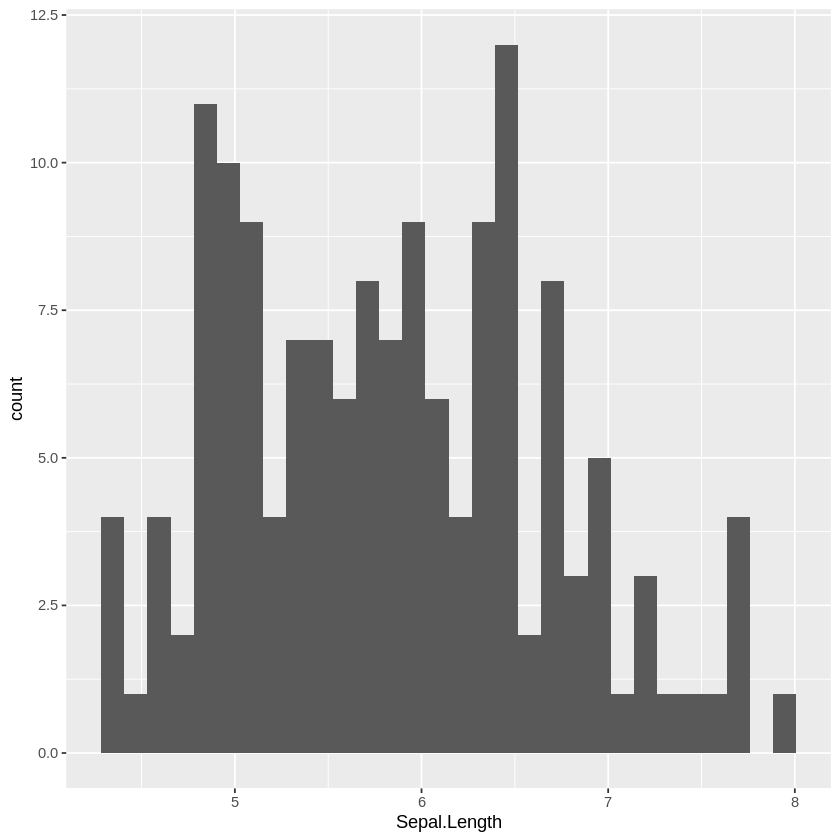

In [15]:
ggplot(data = iris, aes(x = Sepal.Length)) + 
  geom_histogram() 
# aes definuje ktora premenna bude na osi x
# geom_histogram() oznacuje ze chceme vykreslit histogram

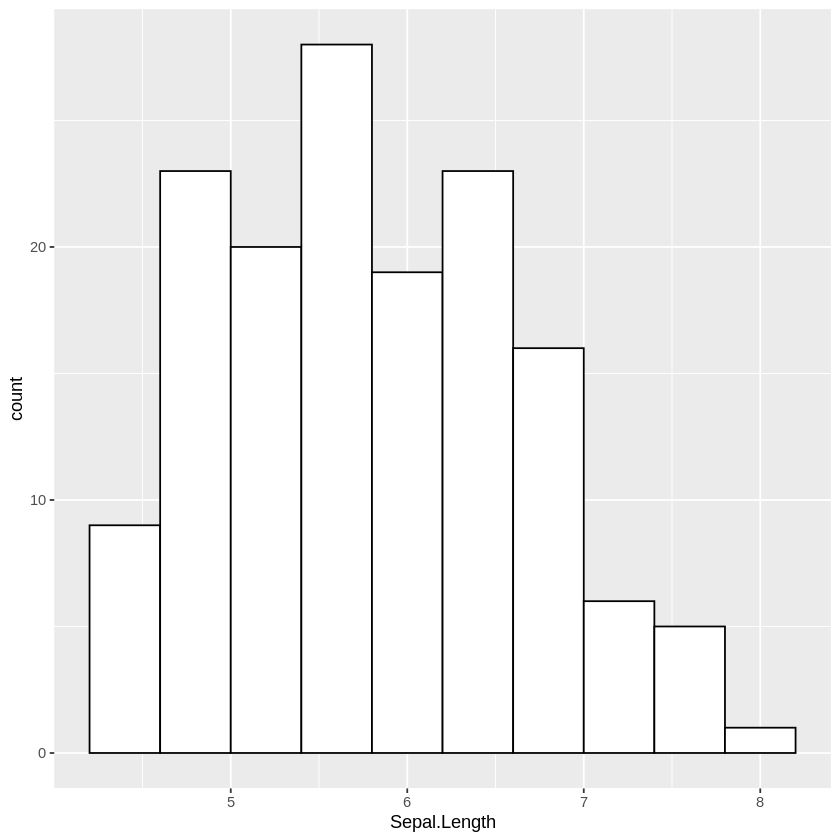

In [16]:
ggplot(iris, aes(x = Sepal.Length)) + 
  geom_histogram(color = "black", fill = "white", bins = 10 )

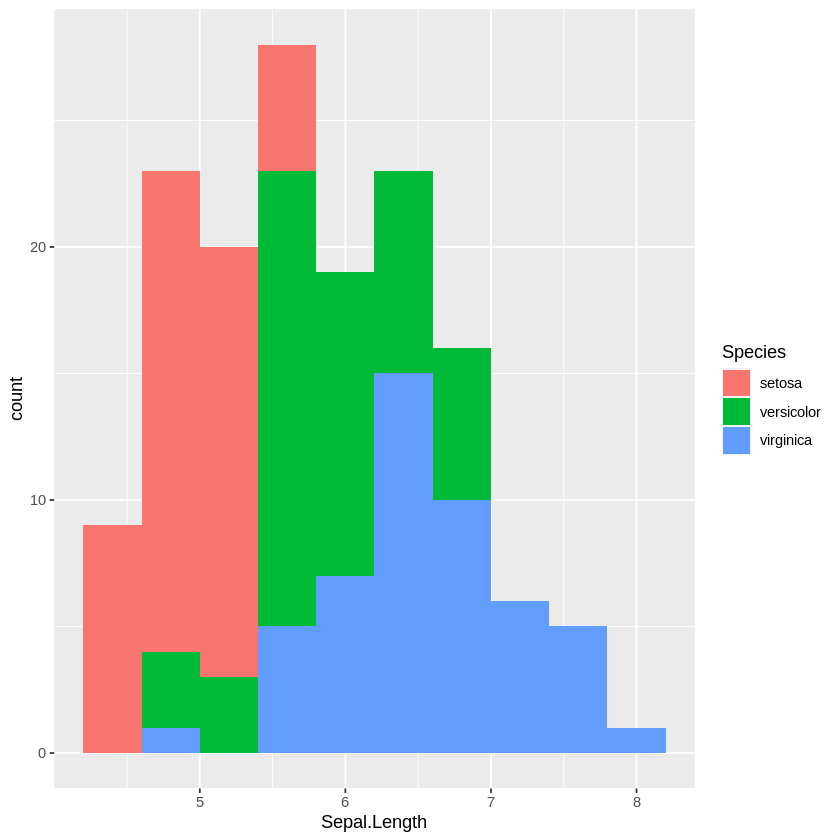

In [17]:
ggplot(iris, aes(x = Sepal.Length, fill = Species)) + 
  geom_histogram(bins = 10)

In [18]:
# Nainštalujte si balíček gridExtra a načítajte knižnicu gridExtra.
install.packages("gridExtra")
library(gridExtra)

Updating HTML index of packages in '.Library'

Making 'packages.html' ...
 done



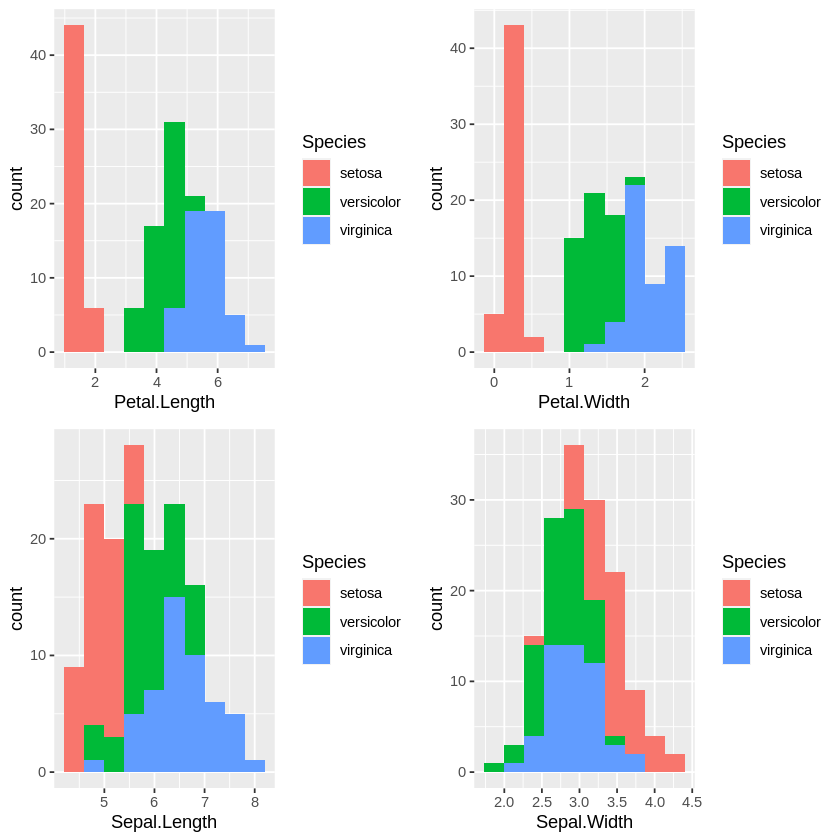

In [19]:
g1 = ggplot(iris, aes(x=Petal.Length, fill=Species)) + 
  geom_histogram(bins = 10)
g2 =  ggplot(iris, aes(x=Petal.Width, fill=Species)) + 
  geom_histogram(bins = 10)
g3 = ggplot(iris, aes(x=Sepal.Length, fill=Species)) + 
  geom_histogram(bins = 10)
g4 = ggplot(iris, aes(x=Sepal.Width, fill=Species)) + 
  geom_histogram(bins = 10)

grid.arrange(g1, g2, g3, g4, nrow = 2)

<h4>Barplot</h4>

In [1]:
# Načítajte si dataset Titanic
titanic = data.frame(Titanic)

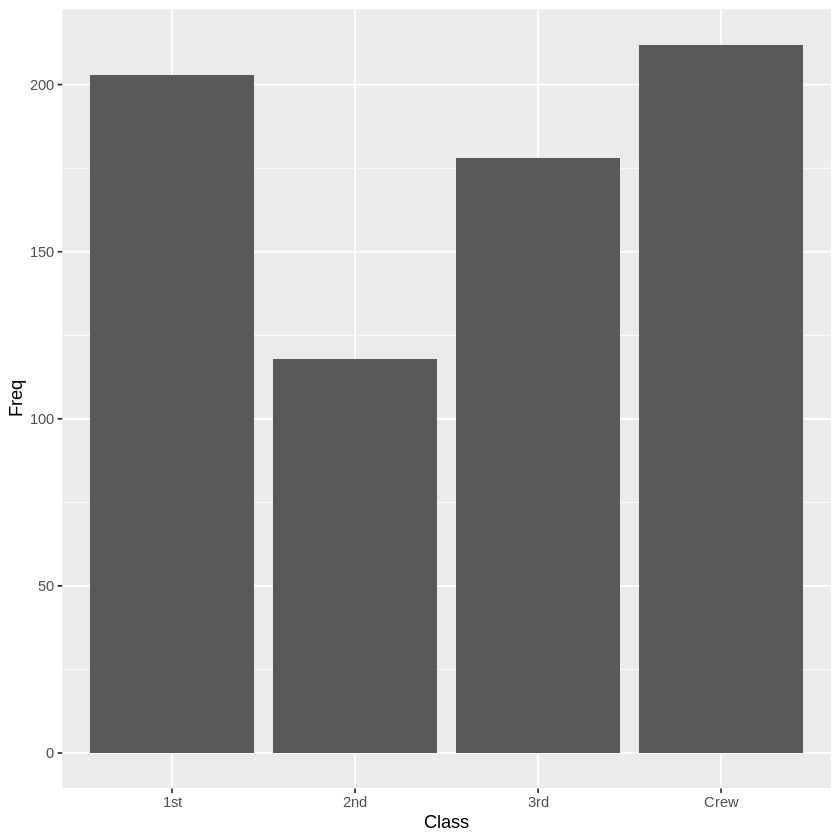

In [21]:
ggplot(titanic[titanic$Survived=="Yes",], aes(x=Class, y=Freq)) +
  geom_bar(stat="identity")

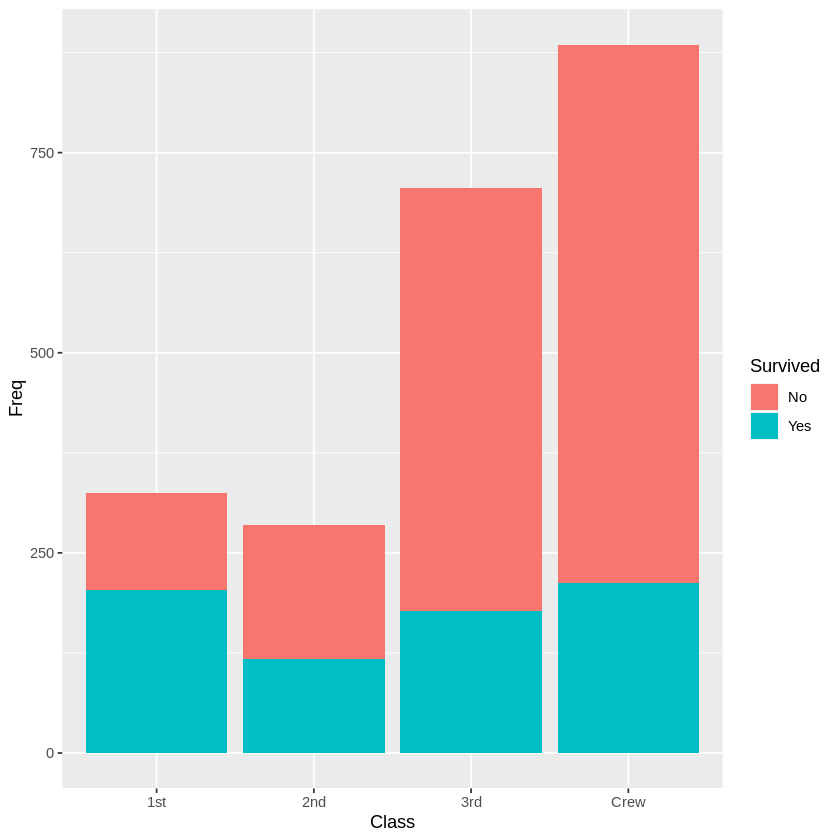

In [22]:
ggplot(titanic, aes(x=Class, y=Freq, fill=Survived)) +
  geom_bar(stat="identity") 

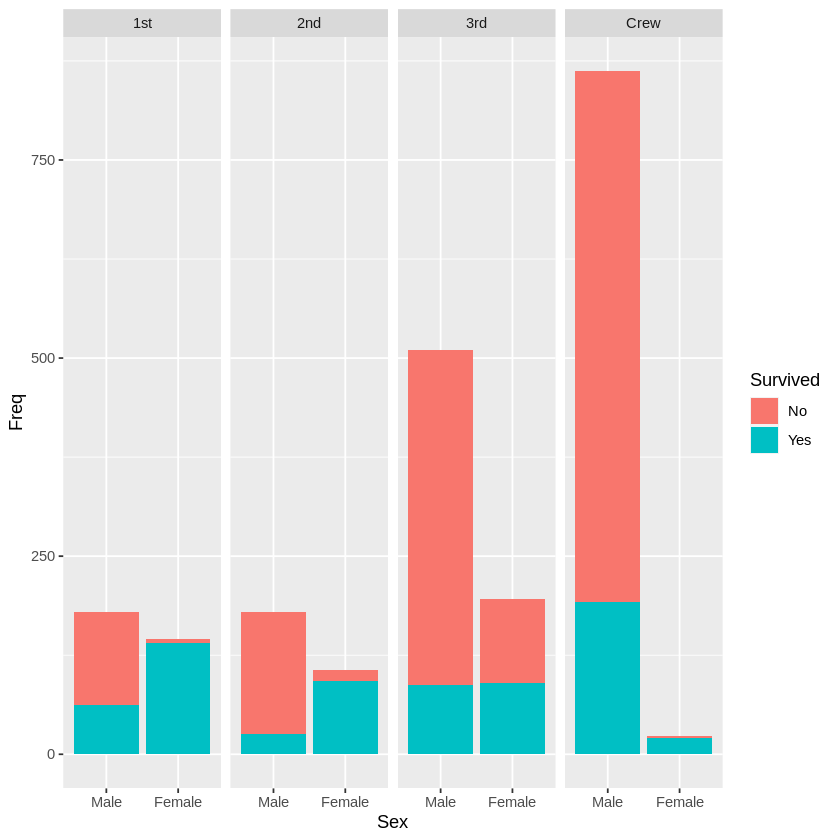

In [23]:
ggplot(titanic, aes(x=Sex, y=Freq, fill=Survived)) +
  geom_bar(stat="identity") +
  facet_grid(~Class)

<h4>Boxplot</h4> 

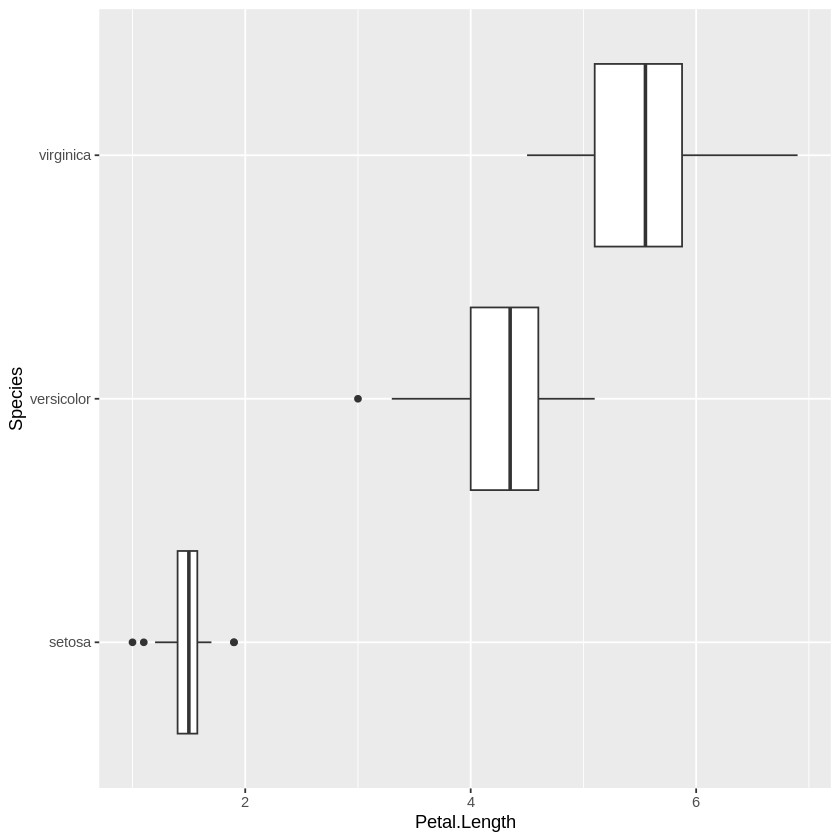

In [24]:
ggplot(iris, aes(x=Species, y=Petal.Length)) + 
  geom_boxplot() +
  coord_flip()

<h4>Scatterplot</h4>

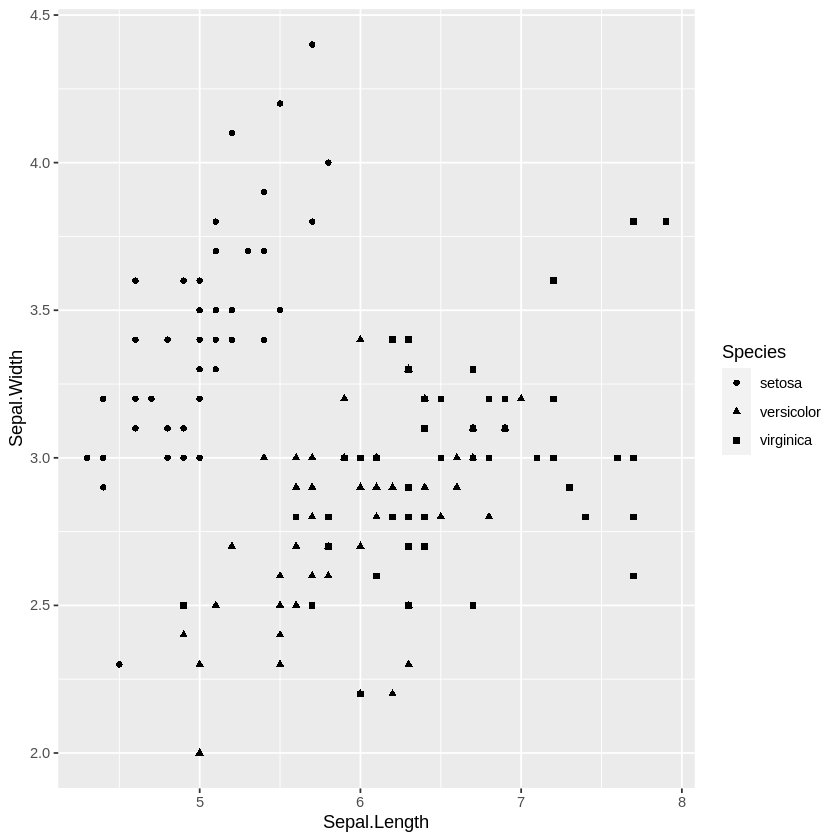

In [25]:
ggplot(iris, aes( x = Sepal.Length, y = Sepal.Width, shape= Species))+
  geom_point() 

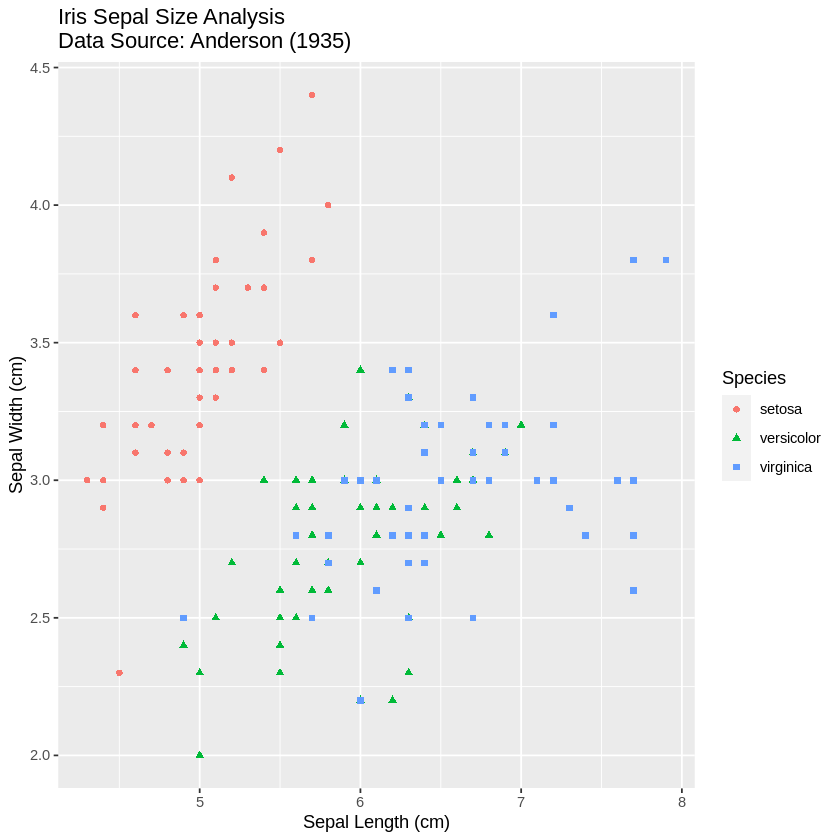

In [26]:
ggplot(iris, aes( x = Sepal.Length, y = Sepal.Width, shape = Species, color = Species)) + 
  geom_point() + 
  ggtitle("Iris Sepal Size Analysis\nData Source: Anderson (1935)") + 
  xlab("Sepal Length (cm)") +
  ylab("Sepal Width (cm)") 

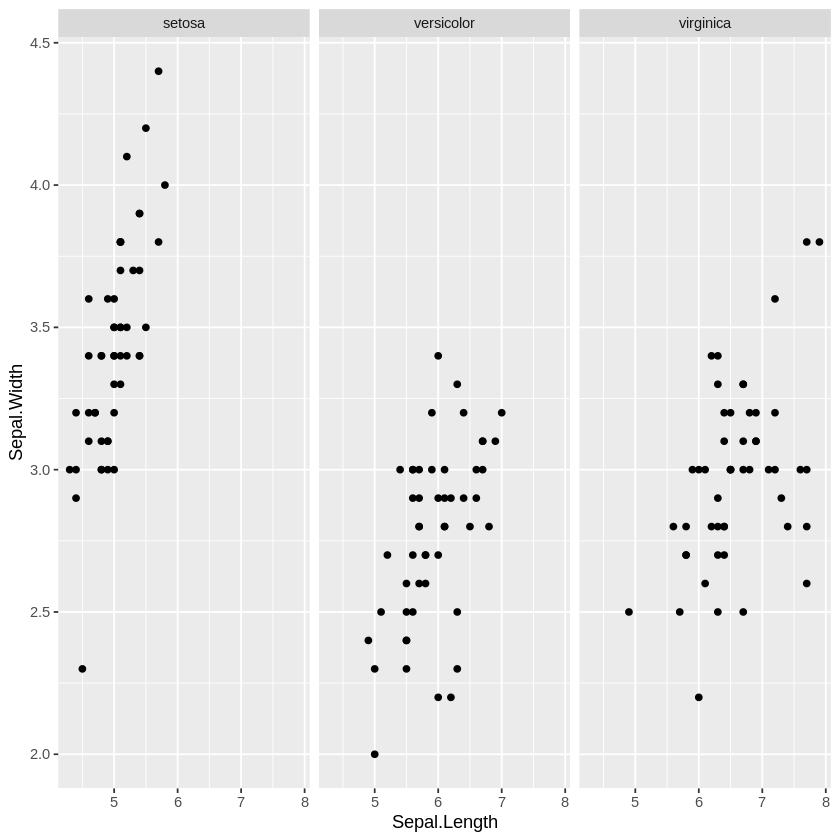

In [27]:
# faceting
ggplot(iris, aes(Sepal.Length, Sepal.Width)) + 
  geom_point() + 
  facet_wrap(~Species)

<h3>Úlohy</h3>
<div class="alert alert-info">
  <h4>Úloha 4.1</h4>
  <p>
    Vytvorte <samp>boxplot</samp> pomocou systému vykresľovania <samp>Base</samp>. Použite dáta z datasetu s názvom <samp>CO2</samp>. 
    Uložte dáta <samp>CO2</samp> do premennej s názvom <samp>CO2</samp>. Boxplot bude znázorňovať závislosť premennej <samp>uptake</samp> ku premennej <samp>Type</samp>. 
    Nastavte farbu boxplotu na zelenú a pridajte taktiež nadpis grafu a popis osí <samp>x</samp> a <samp>y</samp>. 
    Na záver pridajte do grafu horizontálnu hrubú čiaru s veľkosťou 4 na hodnote 25, ktorá bude prerušovaná a červená.
    </p>
</div>
<div class="alert alert-info">
  <h4>Úloha 4.2</h4>
  <p>
    Vytvorte <samp>bodobý graf</samp> pomocou knižnice <samp>ggplot2</samp>. Použite dáta z datasetu s názvom <samp>mtcars</samp>. 
    Bodový graf bude znázorňovať závislosť počtu najazdených kilometrov (<samp>mpg</samp>) ku objemu motora (<samp>disp</samp>) pre autá s manuálnou prevodovkou - (podmnožinu <samp>am==0</samp>). Farbu bodov zvolťe podľa počtu valcov (<samp>cyl</samp>). 
    Pridajte nadpis <samp>Scatter plot</samp>, os <samp>x</samp> premenujte na<samp>Mileage</samp>, os <samp>y</samp> na <samp>Displacement</samp>. Nastavte tému na minimálnu.
    </p>
</div>


<h3>Úlohy na precvičenie</h3>
<div class="alert alert-success">
        <h4>Úloha 4.3</h4>
    <p>Načítajte si dáta <samp>mtcars</samp>. Pomocou systému <samp>Base</samp> vykreslite stĺpcový graf zobrazujúci početnosti áut pre jednotlivé typy motorov - počet válcov <samp>cyl</samp>.
        Jednotlivé stĺpce farebne odlíšte. Pridajte nadpis grafu <samp>Počet áut pre jednotlivé typy motorov</samp>. Pridajte horizontálnu čiaru na hodnote 8, so šírkou čiary 2 a čiernou farbou.
    </p>
    </div>

<div class="alert alert-success">
        <h4>Úloha 4.4</h4>
    <p>Načítajte si dáta <samp>mtcars</samp>. Pomocou systému <samp>Base</samp> vykreslite boxplot grafy pre spotrebu auta <samp>Base</samp> pre rôzny počet prevodových stupňov <samp>gear</samp>.
Pridajte nadpis grafu a zmeňte farby jednotlivých boxplotov.
    </p>
    </div>

<div class="alert alert-success">
        <h4>Úloha 4.5</h4>
    <p>Načítajte si dáta <samp>mtcars</samp>. Pomocou knižnice <samp>ggplot2</samp> vykreslite histogram pre výkon áut - atribút <samp>hp</samp>, rozdeľte na 10 stĺpcov a nastavte výplň podľa počtu válcov <samp>cyl</samp>.
    </p>
    </div>

<div class="alert alert-success">
        <h4>Úloha 4.5</h4>
    <p>Načítajte si dáta <samp>mtcars</samp>. Pomocou knižnice <samp>ggplot2</samp> riešte úlohu 4.4.
    </p>
    </div>